In [3]:
import importlib
from pathlib import Path
from IPython.display import display

try:
    import helpers.elements_3d as e3d
    import helpers.preprocess as prep
    import helpers.postprocess as post
    import helpers.solver as solv
    import helpers.output_writer as ow
    import helpers.plotting_simple as ps
    import helpers.plotting_plotly as pp3d

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)
    importlib.reload(ps)
    importlib.reload(pp3d)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
    from helpers.plotting_simple import plot_structure_simple
    from helpers.plotting_plotly import plot_structure_plotly

except ImportError:
    import elements_3d as e3d
    import preprocess as prep
    import postprocess as post
    import solver as solv
    import output_writer as ow
    import plotting_simple as ps
    import plotting_plotly as pp3d

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)
    importlib.reload(ps)
    importlib.reload(pp3d)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs
    from plotting_simple import plot_structure_simple
    from plotting_plotly import plot_structure_plotly

model_path = "inputs/final_bridge/scenario_weakened_floor_beam_from_deadload.json"

In [4]:
_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

print("Model ran successfully")
print()
print("Model name")
print(clean_model["model_name"])
print()
print("Total DOF")
print(data["ndof"])
print()
print("Number of elements")
print(len(clean_model["elements"]))
print()
print("Max absolute displacement")
print(abs(package["results"]["U"]).max())

Model ran successfully

Model name
scenario_weakened_floor_beam_from_deadload

Total DOF
234

Number of elements
91

Max absolute displacement
0.0008330200639471275


In [5]:
output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print(f"Outputs saved to {output_dir}")
print()
print(list(tables.keys()))

Outputs saved to outputs\runs\scenario_weakened_floor_beam_from_deadload

['model_summary', 'nodal_loads', 'node_displacements', 'support_reactions', 'element_basic_data', 'element_local_displacements', 'element_local_end_forces', 'element_global_end_forces', 'element_derived_results']


In [6]:
display(tables["model_summary"])
display(tables["node_displacements"])
display(tables["support_reactions"])
display(tables["element_local_end_forces"])
display(tables["element_derived_results"])

,model_name,length_unit,force_unit,n_nodes,n_elements,n_truss_elements,n_frame_elements,n_free_dofs,n_restrained_dofs,max_displacement_node,max_displacement_magnitude
0,scenario_weakened_floor_beam_from_deadload,ft,kip,39,91,59,32,132,102,32,0.000839


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
0,1,0.000,0.0,0.0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
1,2,18.176,0.0,0.0,0.000027,0.000000e+00,-0.000247,0.000000e+00,0.000000,0.000000e+00,0.000249,0.000000
2,3,36.352,0.0,0.0,0.000051,0.000000e+00,-0.000420,0.000000e+00,0.000000,0.000000e+00,0.000423,0.000000
3,4,54.528,0.0,0.0,0.000096,0.000000e+00,-0.000477,0.000000e+00,0.000000,0.000000e+00,0.000487,0.000000
4,5,72.704,0.0,0.0,0.000141,0.000000e+00,-0.000426,0.000000e+00,0.000000,0.000000e+00,0.000449,0.000000
5,6,90.880,0.0,0.0,0.000167,0.000000e+00,-0.000264,0.000000e+00,0.000000,0.000000e+00,0.000312,0.000000
6,7,109.055,0.0,0.0,0.000197,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000197,0.000000
7,8,18.176,0.0,20.0,0.000176,0.000000e+00,-0.000241,0.000000e+00,0.000000,0.000000e+00,0.000299,0.000000
8,9,36.352,0.0,20.0,0.000139,0.000000e+00,-0.000425,0.000000e+00,0.000000,0.000000e+00,0.000447,0.000000
9,10,54.528,0.0,20.0,0.000098,0.000000e+00,-0.000472,0.000000e+00,0.000000,0.000000e+00,0.000482,0.000000


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.000,0.0,0.0,-0.034212,0.000000,6.901927,0.000000,0.000000,0.000000,6.902012,0.000000
1,2,18.176,0.0,0.0,0.000000,-0.022397,0.000000,4.926213,-0.313128,2.981198,0.022397,5.766556
2,3,36.352,0.0,0.0,0.000000,0.013845,0.000000,13.674177,-0.371890,2.093867,0.013845,13.838558
3,4,54.528,0.0,0.0,0.000000,0.016649,0.000000,12.440431,-0.058533,0.013442,0.016649,12.440576
4,5,72.704,0.0,0.0,0.000000,0.014317,0.000000,13.837648,-0.097954,-2.031498,0.014317,13.986318
5,6,90.880,0.0,0.0,0.000000,-0.022413,0.000000,8.934906,-0.149166,-3.057498,0.022413,9.444739
6,7,109.055,0.0,0.0,0.000000,0.000000,7.617401,0.000000,0.000000,0.000000,7.617401,0.000000
7,8,18.176,0.0,20.0,0.000000,2.865580,0.000000,0.000000,0.000000,0.000000,2.865580,0.000000
8,9,36.352,0.0,20.0,0.000000,6.049746,0.000000,0.000000,0.000000,0.000000,6.049746,0.000000
9,10,54.528,0.0,20.0,0.000000,6.351509,0.000000,0.000000,0.000000,0.000000,6.351509,0.000000


,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,101,3D_truss,1,2,-6.261243,0.0,0.0,0.0,0.0,0.0,6.261243,0.0,0.0,0.0,0.0,0.0
1,102,3D_truss,2,3,-5.367515,0.0,0.0,0.0,0.0,0.0,5.367515,0.0,0.0,0.0,0.0,0.0
2,103,3D_truss,3,4,-10.359356,0.0,0.0,0.0,0.0,0.0,10.359356,0.0,0.0,0.0,0.0,0.0
3,104,3D_truss,4,5,-10.492229,0.0,0.0,0.0,0.0,0.0,10.492229,0.0,0.0,0.0,0.0,0.0
4,105,3D_truss,5,6,-5.958825,0.0,0.0,0.0,0.0,0.0,5.958825,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,509,3D_truss,21,10,4.262283,0.0,0.0,0.0,0.0,0.0,-4.262283,0.0,0.0,0.0,0.0,0.0
87,510,3D_truss,10,23,4.320290,0.0,0.0,0.0,0.0,0.0,-4.320290,0.0,0.0,0.0,0.0,0.0
88,511,3D_truss,22,11,4.319102,0.0,0.0,0.0,0.0,0.0,-4.319102,0.0,0.0,0.0,0.0,0.0
89,512,3D_truss,11,24,4.035066,0.0,0.0,0.0,0.0,0.0,-4.035066,0.0,0.0,0.0,0.0,0.0


,elem_id,type,node_i,node_j,L,axial_i_local,axial_j_local,axial_abs_max,shear_y_abs_max,shear_z_abs_max,torsion_abs_max,moment_y_abs_max,moment_z_abs_max,moment_abs_max,stress_axial_i,stress_axial_j,stress_axial_abs_max
0,101,3D_truss,1,2,18.176000,-6.261243,6.261243,6.261243,0.0,0.0,0.0,0.0,0.0,0.0,-6.261243,6.261243,6.261243
1,102,3D_truss,2,3,18.176000,-5.367515,5.367515,5.367515,0.0,0.0,0.0,0.0,0.0,0.0,-5.367515,5.367515,5.367515
2,103,3D_truss,3,4,18.176000,-10.359356,10.359356,10.359356,0.0,0.0,0.0,0.0,0.0,0.0,-10.359356,10.359356,10.359356
3,104,3D_truss,4,5,18.176000,-10.492229,10.492229,10.492229,0.0,0.0,0.0,0.0,0.0,0.0,-10.492229,10.492229,10.492229
4,105,3D_truss,5,6,18.176000,-5.958825,5.958825,5.958825,0.0,0.0,0.0,0.0,0.0,0.0,-5.958825,5.958825,5.958825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,509,3D_truss,21,10,27.025303,4.262283,-4.262283,4.262283,0.0,0.0,0.0,0.0,0.0,0.0,4.262283,-4.262283,4.262283
87,510,3D_truss,10,23,27.025303,4.320290,-4.320290,4.320290,0.0,0.0,0.0,0.0,0.0,0.0,4.320290,-4.320290,4.320290
88,511,3D_truss,22,11,27.025303,4.319102,-4.319102,4.319102,0.0,0.0,0.0,0.0,0.0,0.0,4.319102,-4.319102,4.319102
89,512,3D_truss,11,24,27.025303,4.035066,-4.035066,4.035066,0.0,0.0,0.0,0.0,0.0,0.0,4.035066,-4.035066,4.035066


In [7]:
plot_dir_simple = Path("outputs/final_bridge/simple_plots")
plot_dir_plotly = Path("outputs/final_bridge/plotly_plots")

plot_dir_simple.mkdir(parents=True, exist_ok=True)
plot_dir_plotly.mkdir(parents=True, exist_ok=True)

simple_undeformed = plot_dir_simple / "scenario_weakened_floor_beam_from_deadload_undeformed.png"
simple_def_undef = plot_dir_simple / "scenario_weakened_floor_beam_from_deadload_undeformed_plus_deformed.png"

plotly_undef_html = plot_dir_plotly / "scenario_weakened_floor_beam_from_deadload_undeformed.html"
plotly_undef_png  = plot_dir_plotly / "scenario_weakened_floor_beam_from_deadload_undeformed.png"

plotly_def_html = plot_dir_plotly / "scenario_weakened_floor_beam_from_deadload_undeformed_plus_deformed.html"
plotly_def_png  = plot_dir_plotly / "scenario_weakened_floor_beam_from_deadload_undeformed_plus_deformed.png"

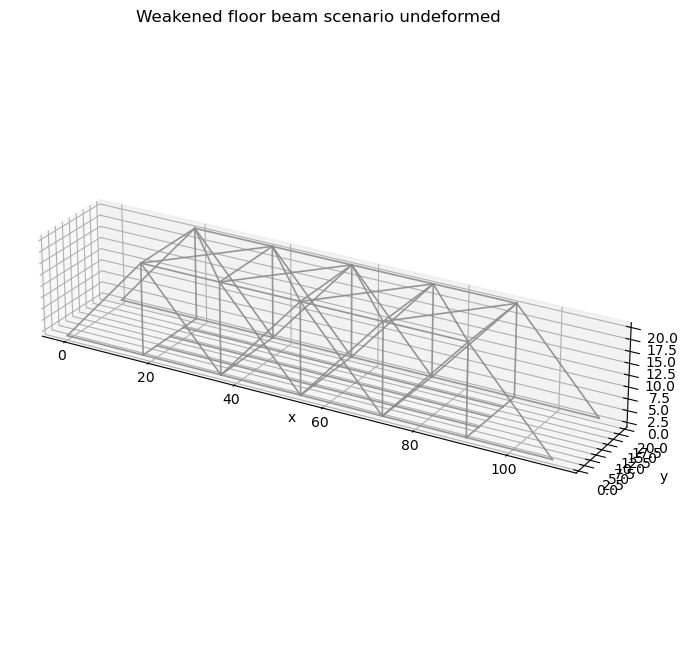

Saved outputs\final_bridge\simple_plots\scenario_weakened_floor_beam_from_deadload_undeformed.png


In [8]:
_ = plot_structure_simple(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_node_labels=False,
    show_element_labels=False,
    title="Weakened floor beam scenario undeformed",
    save_path=str(simple_undeformed),
)

print(f"Saved {simple_undeformed}")

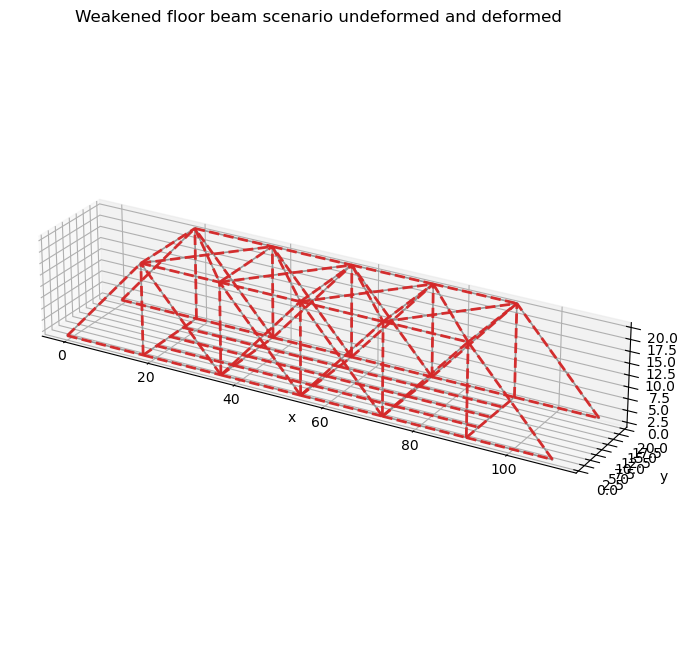

Saved outputs\final_bridge\simple_plots\scenario_weakened_floor_beam_from_deadload_undeformed_plus_deformed.png


In [9]:
_ = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=80.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=False,
    show_element_labels=False,
    title="Weakened floor beam scenario undeformed and deformed",
    save_path=str(simple_def_undef),
)

print(f"Saved {simple_def_undef}")

In [10]:
fig_undef = plot_structure_plotly(
    clean_model,
    data,
    U=None,
    scale=1.0,
    selector="all",
    show_undeformed=True,
    show_deformed=False,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=True,
    show_member_loads=False,
    title="Weakened floor beam scenario undeformed",
    save_html=str(plotly_undef_html),
    save_png=str(plotly_undef_png),
)

fig_undef.show()

print(f"Saved {plotly_undef_html}")
print(f"Saved {plotly_undef_png}")

Saved outputs\final_bridge\plotly_plots\scenario_weakened_floor_beam_from_deadload_undeformed.html
Saved outputs\final_bridge\plotly_plots\scenario_weakened_floor_beam_from_deadload_undeformed.png


In [18]:
fig_def = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=8000.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=False,
    show_node_labels=False,
    show_element_hover=False,
    show_member_loads=False,
    title="Weakened floor beam scenario undeformed and deformed",
    save_html=str(plotly_def_html),
    save_png=str(plotly_def_png),
)

fig_def.show()

print(f"Saved {plotly_def_html}")
print(f"Saved {plotly_def_png}")

Saved outputs\final_bridge\plotly_plots\scenario_weakened_floor_beam_from_deadload_undeformed_plus_deformed.html
Saved outputs\final_bridge\plotly_plots\scenario_weakened_floor_beam_from_deadload_undeformed_plus_deformed.png


In [12]:
import pandas as pd

df_nodes = tables["node_displacements"].copy()

if "disp_mag" in df_nodes.columns:
    df_max_disp = df_nodes.sort_values("disp_mag", ascending=False)[
        ["node_id", "x", "y", "z", "ux", "uy", "uz", "disp_mag"]
    ].head(12)
else:
    df_nodes["disp_mag_calc"] = (df_nodes["ux"]**2 + df_nodes["uy"]**2 + df_nodes["uz"]**2) ** 0.5
    df_max_disp = df_nodes.sort_values("disp_mag_calc", ascending=False)[
        ["node_id", "x", "y", "z", "ux", "uy", "uz", "disp_mag_calc"]
    ].head(12)

display(df_max_disp)

,node_id,x,y,z,ux,uy,uz,disp_mag
31,32,54.528,10.0,0.0,0.000097,5.282421e-10,-0.000833,0.000839
32,33,54.528,15.0,0.0,0.000097,1.339497e-07,-0.000692,0.000699
30,31,54.528,5.0,0.0,0.000097,-1.328923e-07,-0.000690,0.000697
34,35,72.704,10.0,0.0,0.000090,1.485854e-10,-0.000526,0.000533
28,29,36.352,10.0,0.0,0.000103,3.821081e-11,-0.000518,0.000529
35,36,72.704,15.0,0.0,0.000105,2.886757e-08,-0.000487,0.000498
33,34,72.704,5.0,0.0,0.000105,-2.856960e-08,-0.000485,0.000496
15,16,54.528,20.0,0.0,0.000096,0.000000e+00,-0.000480,0.000489
29,30,36.352,15.0,0.0,0.000088,2.770399e-08,-0.000480,0.000488
3,4,54.528,0.0,0.0,0.000096,0.000000e+00,-0.000477,0.000487


In [13]:
df_react = tables["support_reactions"].copy()
display(df_react[["node_id", "x", "y", "z", "Rx", "Ry", "Rz", "Mx", "My", "Mz"]])

,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz
0,1,0.000,0.0,0.0,-0.034212,0.000000,6.901927,0.000000,0.000000,0.000000
1,2,18.176,0.0,0.0,0.000000,-0.022397,0.000000,4.926213,-0.313128,2.981198
2,3,36.352,0.0,0.0,0.000000,0.013845,0.000000,13.674177,-0.371890,2.093867
3,4,54.528,0.0,0.0,0.000000,0.016649,0.000000,12.440431,-0.058533,0.013442
4,5,72.704,0.0,0.0,0.000000,0.014317,0.000000,13.837648,-0.097954,-2.031498
5,6,90.880,0.0,0.0,0.000000,-0.022413,0.000000,8.934906,-0.149166,-3.057498
6,7,109.055,0.0,0.0,0.000000,0.000000,7.617401,0.000000,0.000000,0.000000
7,8,18.176,0.0,20.0,0.000000,2.865580,0.000000,0.000000,0.000000,0.000000
8,9,36.352,0.0,20.0,0.000000,6.049746,0.000000,0.000000,0.000000,0.000000
9,10,54.528,0.0,20.0,0.000000,6.351509,0.000000,0.000000,0.000000,0.000000


In [14]:
df_local = tables["element_local_end_forces"].copy()
df_frame = df_local[df_local["type"] == "3D_frame"].copy()

df_frame["max_abs_end_moment"] = df_frame[
    ["Mx_i_local", "My_i_local", "Mz_i_local", "Mx_j_local", "My_j_local", "Mz_j_local"]
].abs().max(axis=1)

display(df_frame.sort_values("max_abs_end_moment", ascending=False).head(12))

,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local,max_abs_end_moment
58,313,3D_frame,5,34,0.014317,-0.636075,3.566824,-0.097954,-13.837648,-2.031498,-0.014317,0.636075,-3.466824,0.097954,-3.829804,-1.148879,13.837648
61,316,3D_frame,36,17,0.014466,0.638762,-3.487152,0.097675,3.895596,1.152979,-0.014466,-0.638762,3.587152,-0.097675,13.706831,2.040830,13.706831
50,305,3D_frame,3,28,0.013845,0.656333,3.527322,-0.371890,-13.674177,2.093867,-0.013845,-0.656333,-3.427322,0.371890,-3.795769,1.187798,13.674177
53,308,3D_frame,30,15,0.013883,-0.659766,-3.447519,0.372198,3.861952,-1.195437,-0.013883,0.659766,3.547519,-0.372198,13.542311,-2.103395,13.542311
54,309,3D_frame,4,31,0.016649,0.004815,3.229429,-0.058533,-12.440431,0.013442,-0.016649,-0.004815,-3.129429,0.058533,-3.540049,0.010632,12.440431
57,312,3D_frame,33,16,0.016781,-0.004916,-3.157340,0.058530,3.565370,-0.010985,-0.016781,0.004916,3.257340,-0.058530,12.387996,-0.013592,12.387996
62,317,3D_frame,6,37,-0.022413,-0.918050,2.315297,-0.149166,-8.934906,-3.057498,0.022413,0.918050,-2.215297,0.149166,-2.474913,-1.532755,8.934906
65,320,3D_frame,39,18,-0.022679,0.922822,-2.239009,0.148959,2.523200,1.540269,0.022679,-0.922822,2.339009,-0.148959,8.838509,3.073840,8.838509
60,315,3D_frame,35,36,-0.014392,-0.054468,-0.385230,0.063986,6.017607,0.306624,0.014392,0.054468,0.485230,-0.063986,-3.924790,-0.578963,6.017607
59,314,3D_frame,34,35,-0.014391,0.054351,0.465038,-0.063707,3.859081,0.578319,0.014391,-0.054351,-0.365038,0.063707,-6.017602,-0.306563,6.017602


In [15]:
df_derived = tables["element_derived_results"].copy()

if "axial_force" in df_derived.columns:
    df_truss = df_derived[df_derived["type"] == "3D_truss"].copy()
    df_truss["abs_axial"] = df_truss["axial_force"].abs()
    display(df_truss.sort_values("abs_axial", ascending=False).head(12))
else:
    print("No axial_force column found in element_derived_results")

No axial_force column found in element_derived_results


In [16]:
print("Simple plots")
for p in sorted(plot_dir_simple.iterdir()):
    print(p)

print()
print("Plotly plots")
for p in sorted(plot_dir_plotly.iterdir()):
    print(p)

print()
print("Run output files")
for p in sorted(Path(output_dir).iterdir()):
    print(p.name)

Simple plots
outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed.png
outputs\final_bridge\simple_plots\fort_griffin_revised_baseline_undeformed_plus_deformed.png
outputs\final_bridge\simple_plots\fort_griffin_revised_deadload_undeformed.png
outputs\final_bridge\simple_plots\fort_griffin_revised_deadload_undeformed_plus_deformed.png
outputs\final_bridge\simple_plots\scenario_extreme_missing_diagonals_overload_undeformed.png
outputs\final_bridge\simple_plots\scenario_extreme_missing_diagonals_overload_undeformed_plus_deformed.png
outputs\final_bridge\simple_plots\scenario_weakened_floor_beam_from_deadload_undeformed.png
outputs\final_bridge\simple_plots\scenario_weakened_floor_beam_from_deadload_undeformed_plus_deformed.png

Plotly plots
outputs\final_bridge\plotly_plots\final_01_baseline_full_bridge.html
outputs\final_bridge\plotly_plots\final_01_baseline_full_bridge.png
outputs\final_bridge\plotly_plots\final_02_baseline_floor_system_loads.html
outputs\final_brid